In [80]:
# import necessary modules
import os
from os.path import join as pjoin
import numpy as np
from matplotlib import pyplot as plt
import skrf as rf
from scipy.constants import Boltzmann as kB

pjoin = os.path.join
pbase = os.path.basename

%load_ext autoreload
%autoreload 2


# import relevant classes from highz_exp
from highz_exp.load_trc import TraceLoader
from highz_exp.spec_class import Spectrum
from highz_exp.s_params import S_Params
from highz_exp import plotter, circuit_model
from highz_exp.reflection_proc import reflection_coefficient

cmap = plt.get_cmap('Accent')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
data_path = os.path.expanduser("~/Desktop/High-Z/long_cable")

S11s = S_Params(s_params_files=[pjoin(data_path, fn) 
    for fn in ['62OHM.S1P', '99OHM.S1P', '351OHM.S1P', '699OHM.S1P', 'LNA12.S2P']], 
    labels=['62 Ohm', '99 Ohm', '351 Ohm', '699 Ohm', 'LNA'], 
    colorcode=['coral', 'blue', 'green', 'red', 'orange'])

S11s.resample(S11s.ntwk_dict['LNA'].f)

LNA_SMatrix = S_Params(pjoin(data_path, "LNA12.S2P"), labels='LNA S12')
LNA_SMatrix.resample(S11s.ntwk_dict['LNA'].f)

trc_file = pjoin(data_path, "99_62_OHM.trc")

loader = TraceLoader(trc_file)
trace = loader.load_trace(1)
ohm_99 = Spectrum(trace[0], trace[1], name='8" Cable - 99 Ohm', colorcode='blue').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
trace = loader.load_trace(2)
ohm_62 = Spectrum(trace[0], trace[1], name='8" Cable - 62 Ohm', colorcode='coral').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)

trc_file = pjoin(data_path, "699_885OHM.trc")

loader = TraceLoader(trc_file)

trace = loader.load_trace(1)
ohm_699 = Spectrum(trace[0], trace[1], name='8" Cable - 699 Ohm', colorcode='red').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
trace = loader.load_trace(2)
ohm_885 = Spectrum(trace[0], trace[1], name='8" Cable - 885 Ohm', colorcode='purple').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
trace = loader.load_trace(3)
ohm_351 = Spectrum(trace[0], trace[1], name='8" Cable - 351 Ohm', colorcode='green').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
trace = loader.load_trace(4)
ohm_2413 = Spectrum(trace[0], trace[1], name='8" Cable - 2413 Ohm', colorcode='orange').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)

In [82]:
LNA_Z = S11s.ntwk_dict['LNA'].z[:, 0, 0]

gamma_1 = (50 - LNA_Z) / (LNA_Z + 50)

power_50 = np.abs(circuit_model.johnson_V(300, 50, 1e6) * (1-gamma_1))**2
factor = kB * 300 * 1e6 / power_50

In [83]:
import pickle

with open(pjoin(data_path, 'LNA12_thermo.pkl'), 'rb') as f:
    LNA_temp = pickle.load(f)
    
LNA_temp.resample(S11s.ntwk_dict['LNA'].f)

LNA_noise = LNA_temp.T_sys
LNA_noise_spec = Spectrum(LNA_temp.f, LNA_noise, name='LNA Noise Temperature', colorcode='orange')

for spec in [ohm_99, ohm_62, ohm_699, ohm_885, ohm_351, ohm_2413]:
    spec.resample(S11s.ntwk_dict['LNA'].f)
    spec.s = spec.s / np.abs(LNA_SMatrix.ntwk_dict['LNA S12'].s[:, 1, 0])**2
    
spec_dict = {"62 Ohm": ohm_62, "99 Ohm": ohm_99, 
             "351 Ohm": ohm_351, "699 Ohm": ohm_699}
    

In [84]:
def johnson_power(LNA_S11, load_S11, label, colorcode):
    src_Z = load_S11.z[:, 0, 0]
    LNA_Z = LNA_S11.z[:, 0, 0]
    gamma_1 = (src_Z - LNA_Z) / (LNA_Z + src_Z)
    # power = np.abs(circuit_model.johnson_V(300, src_Z, 1e6) * LNA_Z / (LNA_Z + src_Z))**2
    power = np.abs(circuit_model.johnson_V(300, src_Z, 1e6) * (1 - gamma_1))**2
    spec = Spectrum(load_S11.f, power * factor, name=f'Modeled {label} Thermal Power', colorcode=f'light{colorcode}')
    spec = spec.unit_convert(from_unit='watt', to_unit='kelvin', channel_width=1e6)

    reflect = reflection_coefficient(load_S11, LNA_S11)
    noise = LNA_noise * np.abs(reflect.s[:, 0, 0])**2
    noise_spec = Spectrum(load_S11.f, noise, name=f'Modeled {label} LNA Noise Contribution', colorcode=f'light{colorcode}')
    # spec.s += noise
    return spec, noise_spec

mr_list = []
noise_list = []
for label in ['62 Ohm', '99 Ohm', '351 Ohm', '699 Ohm']:
    spec, noise = johnson_power(S11s.ntwk_dict['LNA'], S11s.ntwk_dict[label], label, 
                                colorcode=S11s.colorcode[label])
    mr_list.append(spec)
    noise_list.append(noise)

# total_V_62 = circuit_model.johnson_V(300, 62.3, 1e6) * (1 - reflection_62.s[:, 0, 0]) + circuit_model.johnson_V(LNA_temp.T_sys, 50, 1e6) * reflection_62.s[:, 0, 0]
# power_62 = np.abs(total_V_62)**2

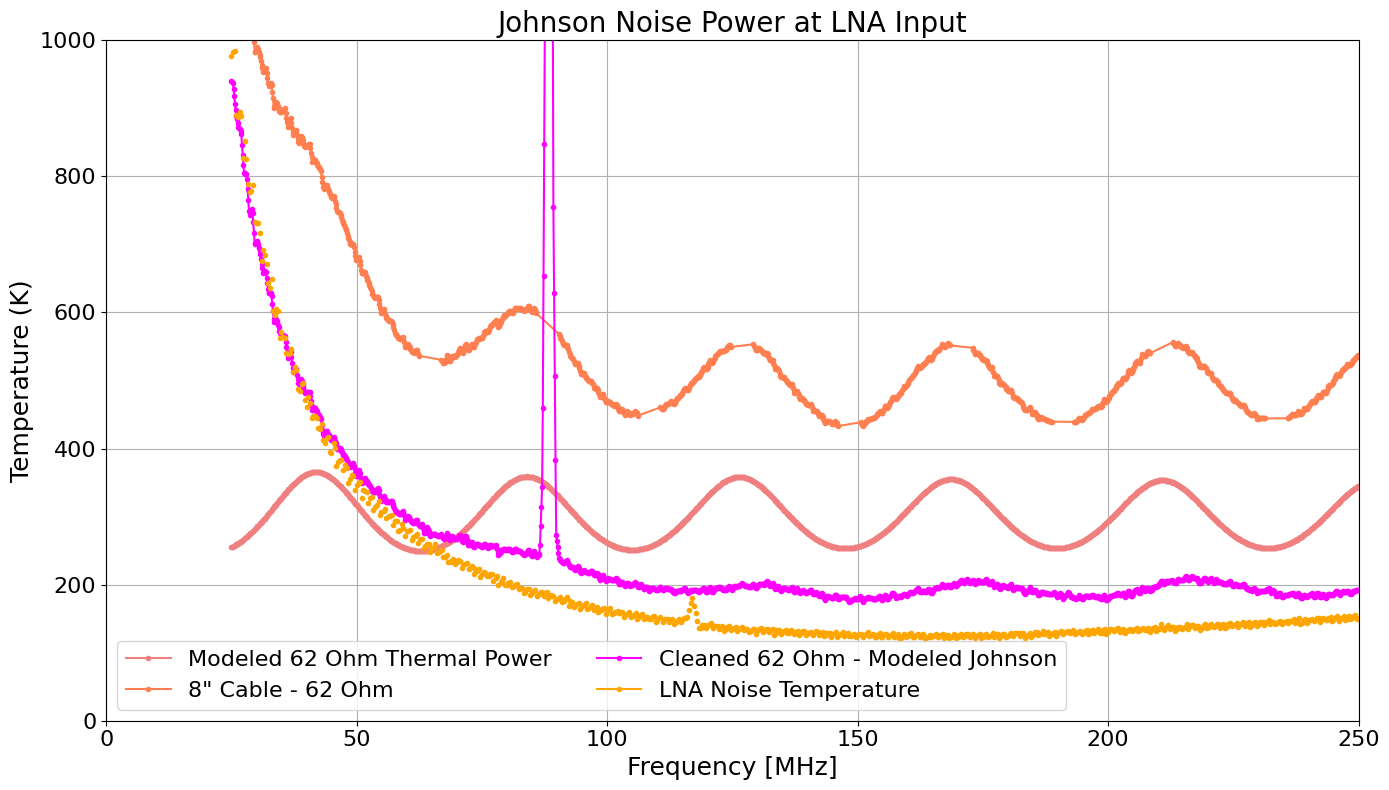

In [87]:
from highz_exp.reflection_proc import remove_spikes

def remove_rfi(kelvin_spec, prominence=50, clean_width=7):
    cleaned_f, cleaned_s = remove_spikes(x=kelvin_spec.f, y=kelvin_spec.s, height=50, prominence=prominence, clean_width=clean_width)
    cleaned_f, cleaned_s = remove_spikes(x=cleaned_f, y=-cleaned_s, prominence=prominence, clean_width=clean_width)
    return Spectrum(cleaned_f, -cleaned_s, name=kelvin_spec.name, colorcode=kelvin_spec.colorcode)

cleaned_62 = remove_rfi(ohm_62, prominence=40, clean_width=15)
# cleaned_351 = remove_rfi(ohm_351, prominence=40, clean_width=15)
subtracted = ohm_62.s - mr_list[0].s
subtracted_spec = Spectrum(ohm_62.f, subtracted, name='Cleaned 62 Ohm - Modeled Johnson', colorcode='magenta')
plotter.plot_spectra([mr_list[0], cleaned_62, subtracted_spec, LNA_noise_spec], title='Johnson Noise Power at LNA Input', 
            ylabel='Temperature (K)', marker='o', ms=3,
            freq_range=(0, 250), y_range=(0, 1000))

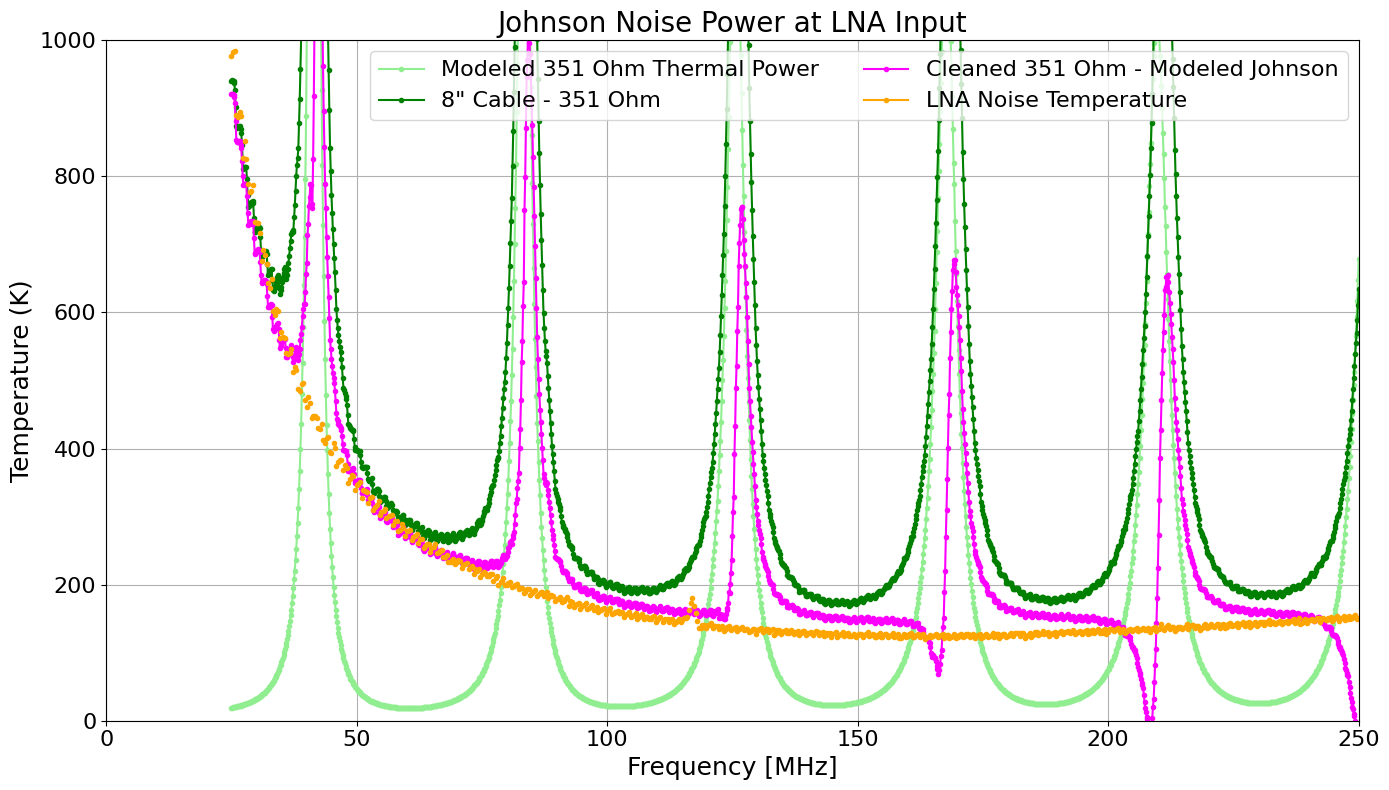

In [86]:
subtracted_spec = Spectrum(ohm_351.f, ohm_351.s - mr_list[2].s, name='Cleaned 351 Ohm - Modeled Johnson', colorcode='magenta')
plotter.plot_spectra([mr_list[2], ohm_351, subtracted_spec, LNA_noise_spec], title='Johnson Noise Power at LNA Input', 
            ylabel='Temperature (K)', marker='o', ms=3,
            freq_range=(0, 250), y_range=(0, 1000))

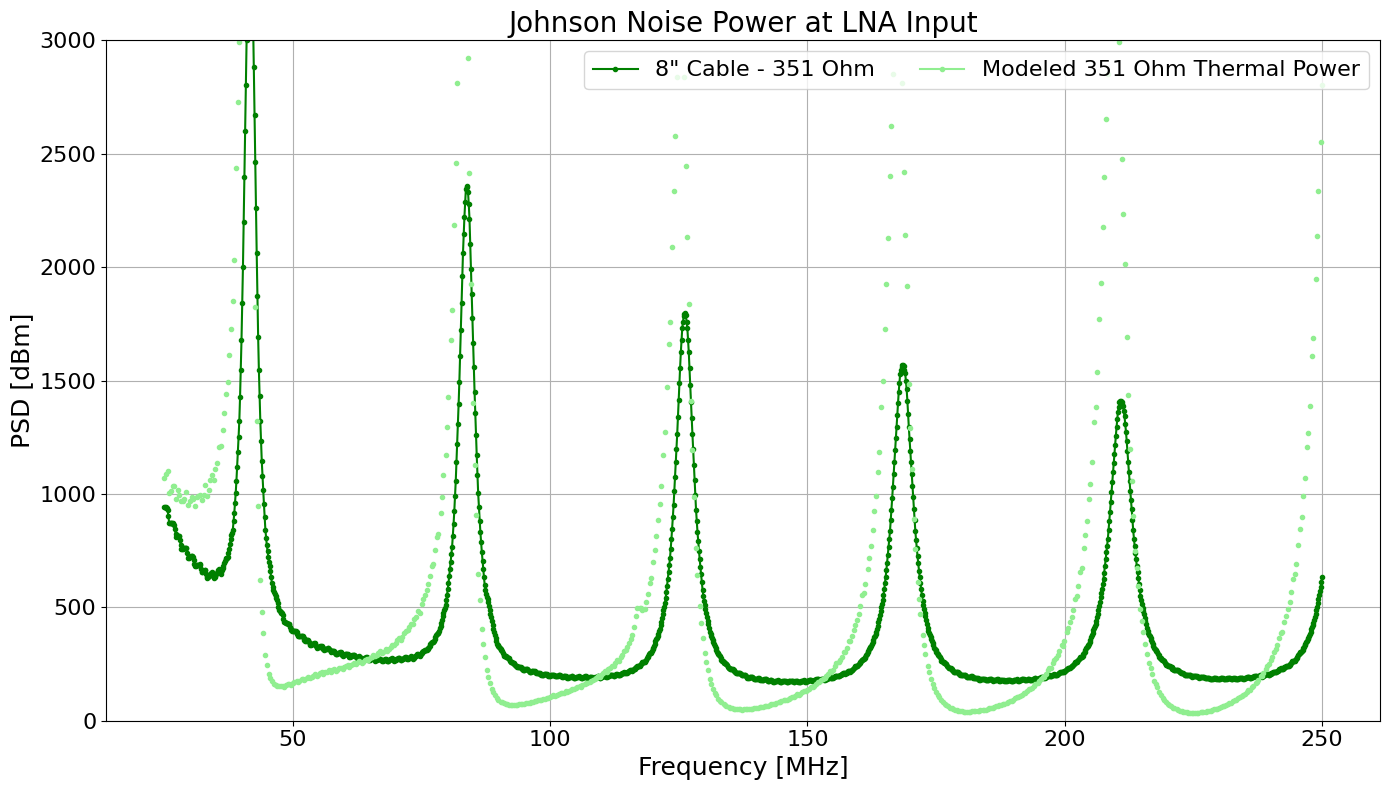

In [59]:
plotter.plot_spectra([ohm_351, mr_list[2]], title='Johnson Noise Power at LNA Input',
                     marker='o', ms=3, y_range=(0, 3000))

In [25]:
noise = (ohm_62.s - spec_62.s) / np.abs(reflection_62.s[:, 0, 0])**2
noise_spec_62 = Spectrum(ohm_62.f, noise, name='62 Ohm Noise Corrected for Reflection', colorcode='purple')

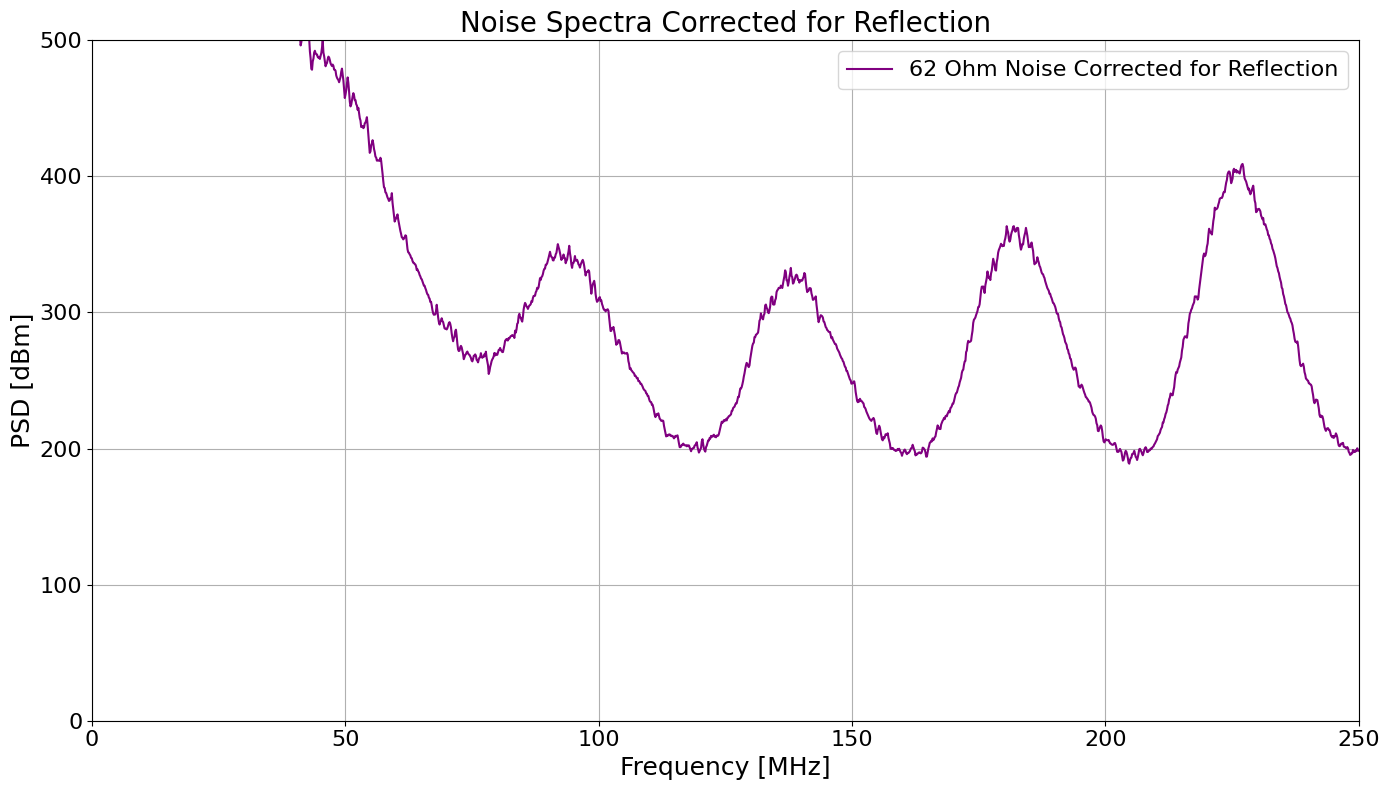

In [26]:
plotter.plot_spectra([noise_spec_62], title='Noise Spectra Corrected for Reflection', 
                     freq_range=(0, 250), y_range=(0, 500))

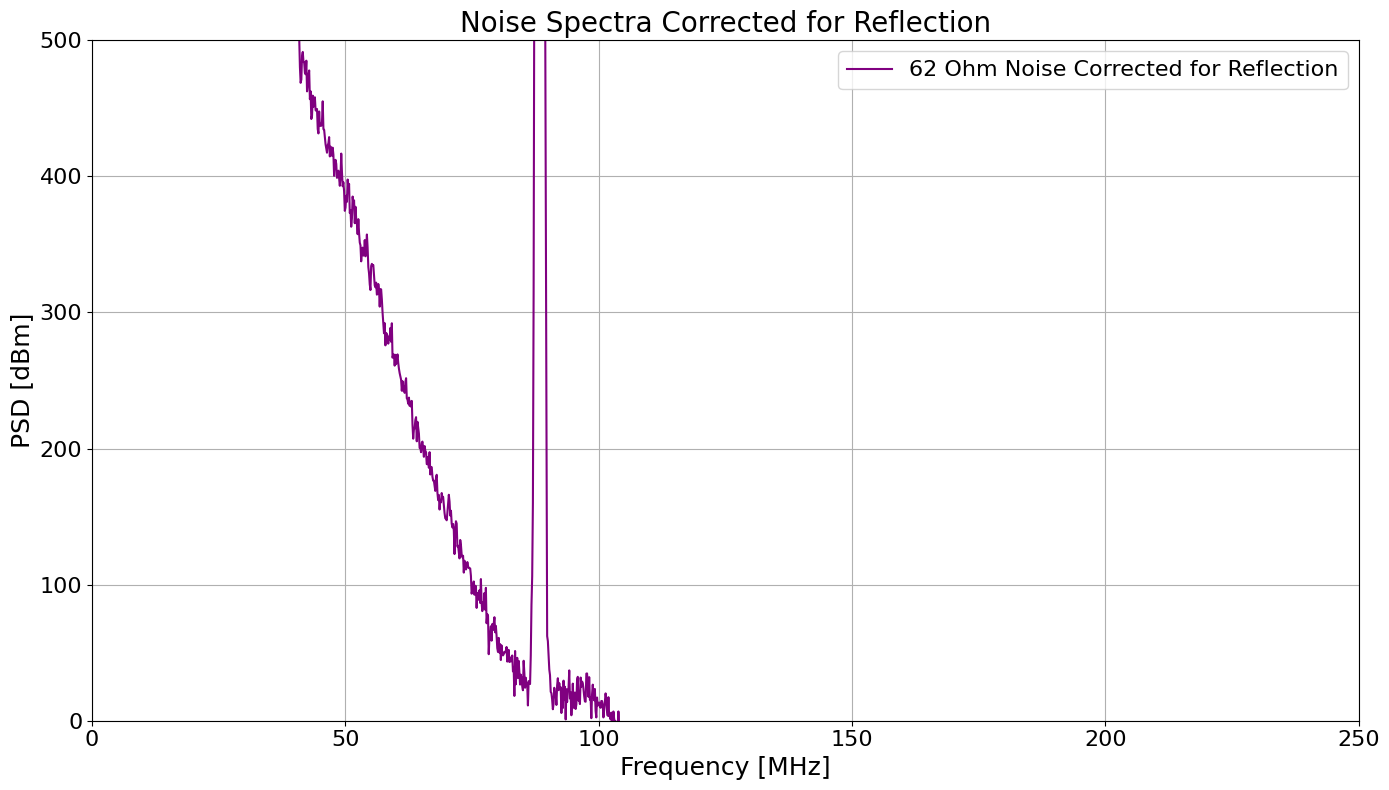

In [ ]:
noise = ohm_699.s / np.abs(reflection_699.s[:, 0, 0])**2
noise_spec_699 = Spectrum(ohm_699.f, noise, name='699 Ohm Noise Corrected for Reflection', colorcode='brown')
noise = ohm_351.s / np.abs(reflection_351.s[:, 0, 0])**2
noise_spec_351 = Spectrum(ohm_351.f, noise, name='351 Ohm Noise Corrected for Reflection', colorcode='green')
noise = ohm_99.s / np.abs(reflection_99.s[:, 0, 0])**2
noise_spec_99 = Spectrum(ohm_99.f, noise, name='99 Ohm Noise Corrected for Reflection', colorcode='blue')


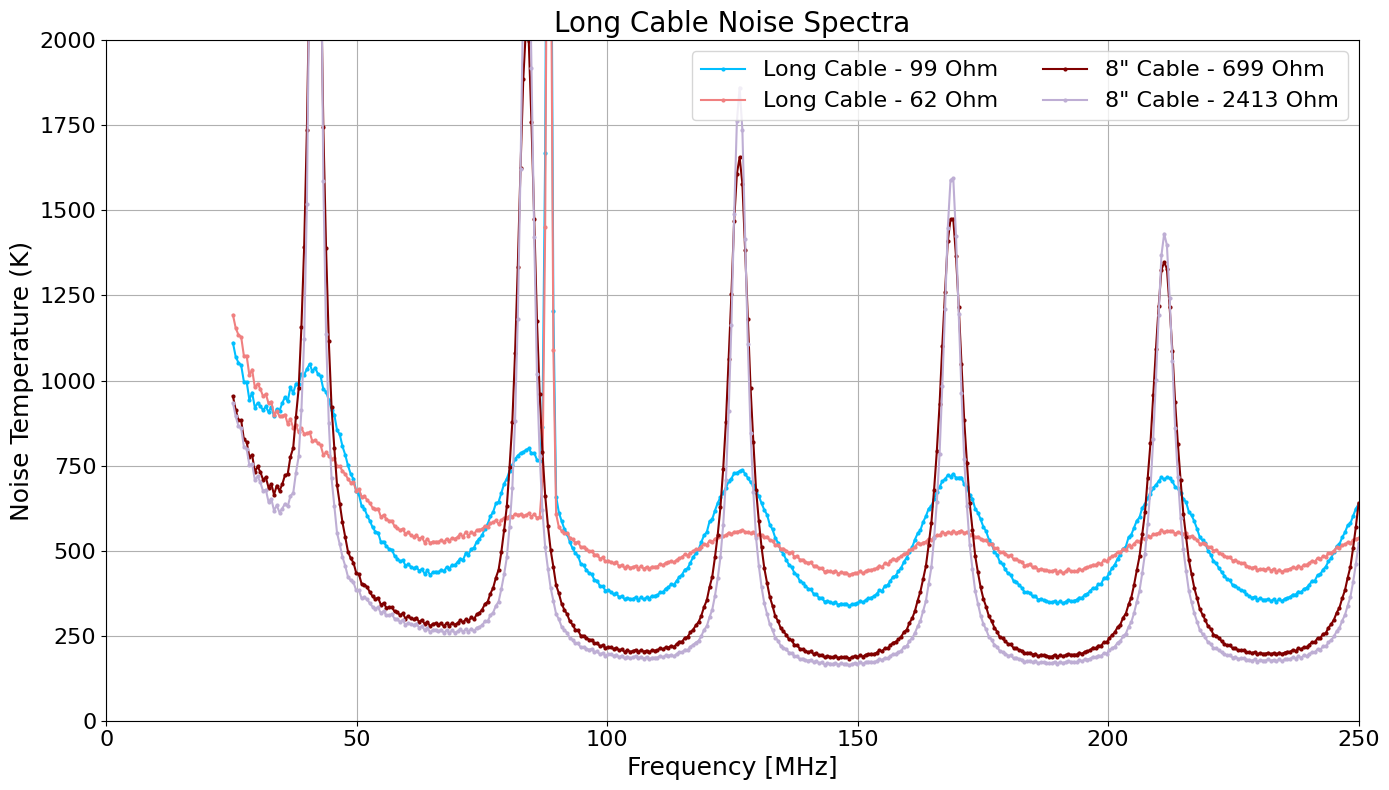

In [32]:
plotter.plot_spectra([ohm_99, ohm_62, ohm_699, ohm_2413], title='Long Cable Noise Spectra', freq_range=(0, 250),
                     ylabel='Noise Temperature (K)', y_range=(0, 2000), marker='o', ms=2)

In [33]:
# frequency axis
chosen_f = ohm_99.f
d = 2.4384 # meters
z_0 = 50
r_l = 99
z_in = S11s.ntwk_dict['99 Ohm'].z[:, 0, 0]
gamma_load = rf.tlineFunctions.zl_2_Gamma0(z_0, r_l)

gamma_in =  rf.tlineFunctions.zl_2_Gamma0(z_0, S11s.ntwk_dict['99 Ohm'].z[:, 0, 0]) # at input
prop_cst = rf.tlineFunctions.reflection_coefficient_2_propagation_constant(gamma_in, gamma_load, d)

In [42]:
r_l_test = 62.3
test_impd = rf.tlineFunctions.zl_2_zin(z_0, r_l_test, theta=prop_cst * d)

(<Figure size 1400x1200 with 1 Axes>,
 <Axes: title={'center': 'Smith Chart'}, xlabel='Real', ylabel='Imaginary'>)

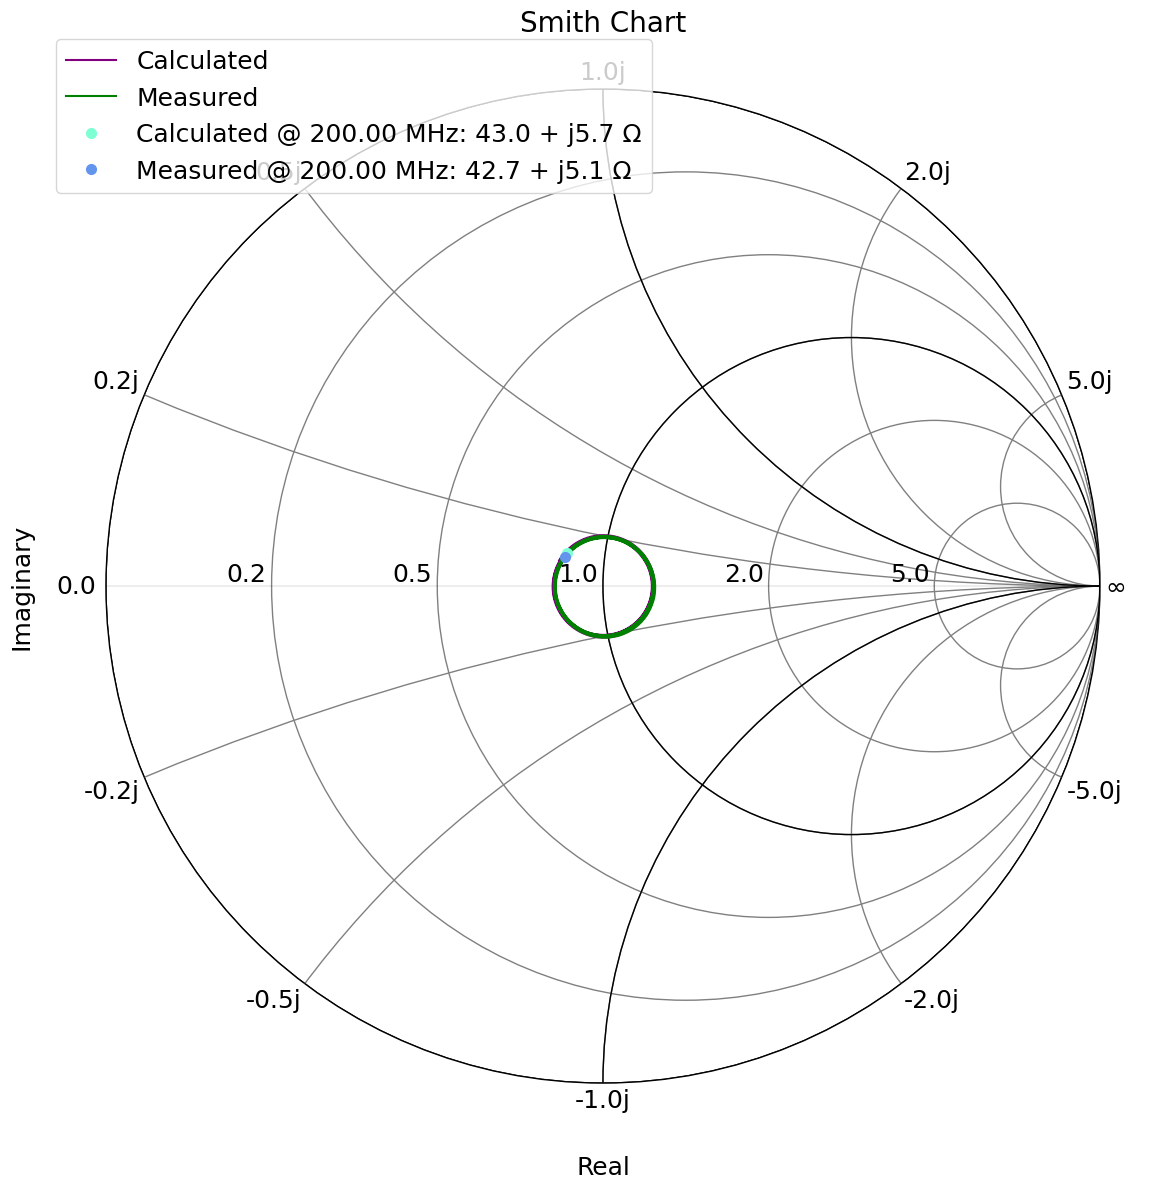

In [43]:
test_ntwk = rf.Network(f=chosen_f, z0=z_0, z=test_impd[:, np.newaxis, np.newaxis])
comparison = S_Params(ntwk_dict={'Calculated': test_ntwk, 'Measured': S11s.ntwk_dict['62 Ohm']}, 
                      colorcode=['purple', 'green'])
comparison.plot_smith_chart(marker_freqs=[200e6])

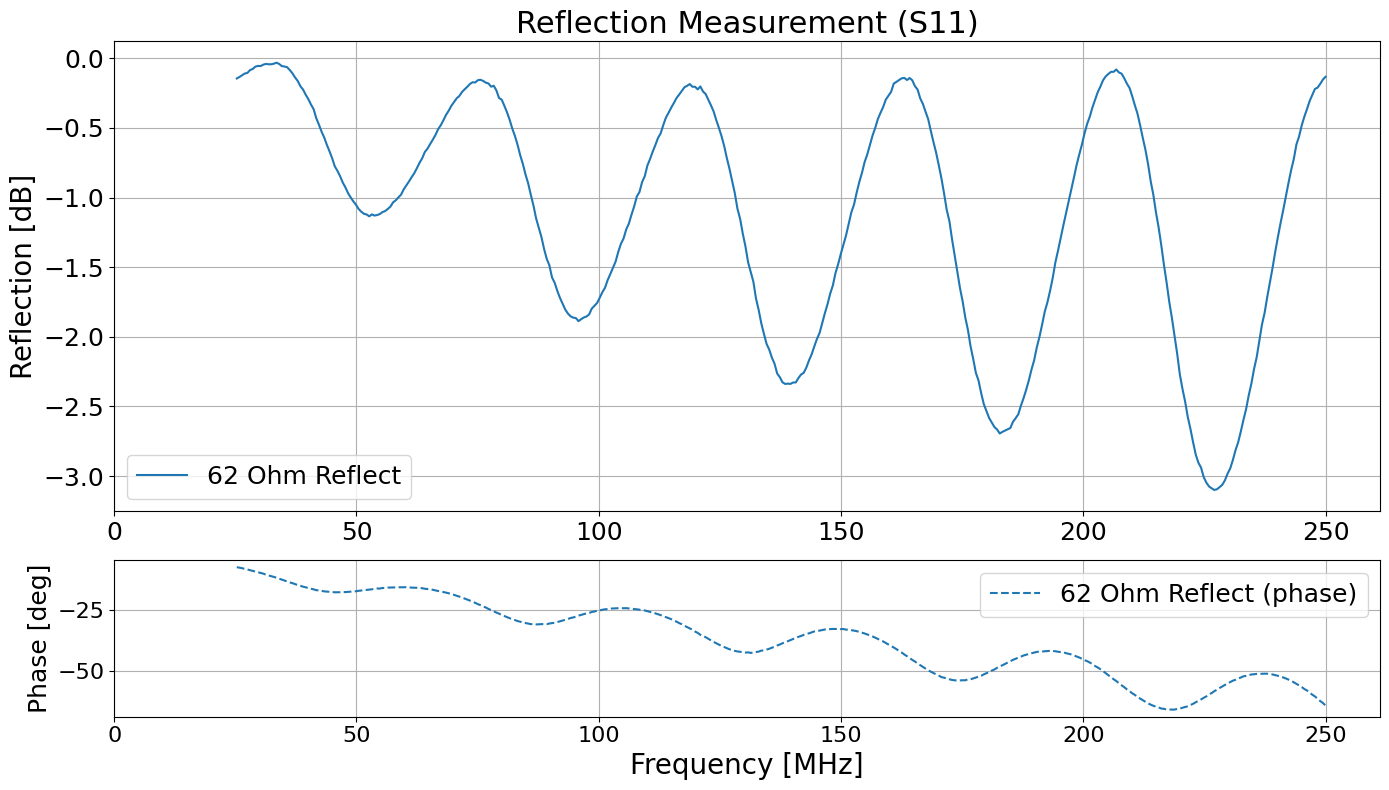

In [ ]:

reflect = S_Params(ntwk_dict={'62 Ohm Reflect': reflect_ntwk}, labels='62 Ohm Reflect', colorcode=['lightcoral'])
reflect.plot_reflection_loss(show_phase=True)
# ant_path = os.path.expanduser("~/Desktop/High-Z/woRelays_wRadials")
# ant_colorcode = {'Ant 1': 'maroon', 'Ant 2': 'olive', 'Ant 3': 'teal', 'Ant 4': 'navy'}
# ant_s11 = S_Params(s_params_files=[pjoin(ant_path, f'Ant{n}.s1p') for n in range(1, 5)],
#                    labels=[f'Ant {n}' for n in range(1, 5)], 
#                    colorcode=ant_colorcode)

In [32]:
def Fmatrix_from_specs(list_of_specs, RBW):
    n_f = len(list_of_specs[0].f)
    n_s = len(list_of_specs)
    F_matrix = np.zeros((n_f, n_s))
    for i, spec in enumerate(list_of_specs):
        spec_T = spec.unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=RBW).s
        F_matrix[:, i] = spec_T
    return F_matrix

In [33]:
F_matrix = Fmatrix_from_specs([ohm_62, ohm_99, ohm_699, ohm_885], RBW=1e6)

/Users/yuntongzhou/Desktop/DevSpace/Highz-EXP/src/highz_exp/unit_convert.py:21: RuntimeWarning: overflow encountered in power
  return 10**(spectrum/10)
/Users/yuntongzhou/Desktop/DevSpace/Highz-EXP/src/highz_exp/unit_convert.py:30: RuntimeWarning: overflow encountered in divide
  return dbm_to_milliwatt(spectrum) * 10**(-3) / channel_width / k_B


In [ ]:


resample_axis = np.arange(25e6, 250e6, 0.5e6)
S11s.interpolate_all(resample_axis)
ant_s11.interpolate_all(resample_axis)


{'Ant 1': 1-Port Network: 'Ant1',  25000000.0-249500000.0 Hz, 450 pts, z0=[50.+0.j],
 'Ant 2': 1-Port Network: 'Ant2',  25000000.0-249500000.0 Hz, 450 pts, z0=[50.+0.j],
 'Ant 3': 1-Port Network: 'Ant3',  25000000.0-249500000.0 Hz, 450 pts, z0=[50.+0.j],
 'Ant 4': 1-Port Network: 'Ant4',  25000000.0-249500000.0 Hz, 450 pts, z0=[50.+0.j]}

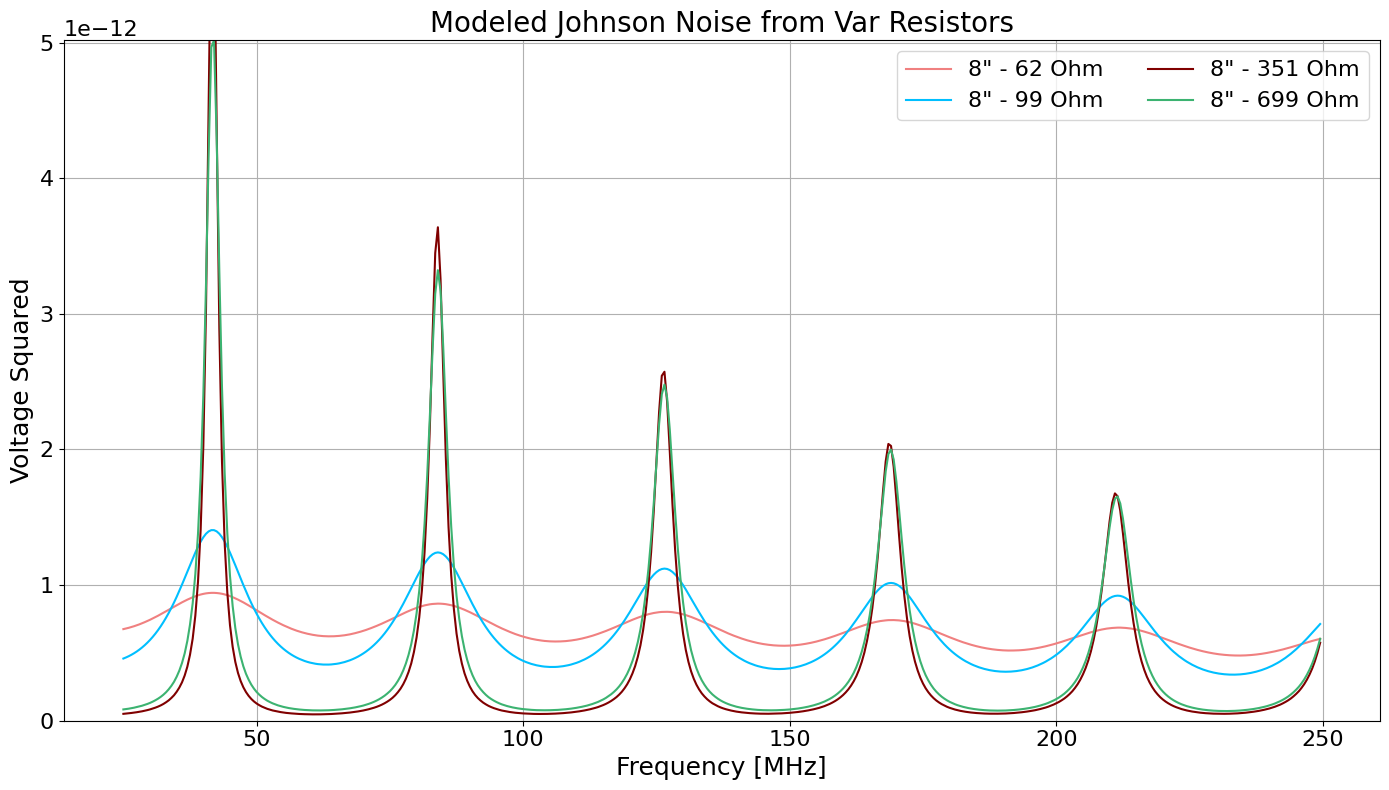

In [21]:
V_62 = LNAModel.V_delivered_from_s11(S11s.ntwk_dict['62 Ohm'], S11s.ntwk_dict['LNA'], 
                                         T_source=300, B=1e6, name='8" - 62 Ohm', colorcode='lightcoral')
V_99 = LNAModel.V_delivered_from_s11(S11s.ntwk_dict['99 Ohm'], S11s.ntwk_dict['LNA'], 
                                         T_source=300, B=1e6, name='8" - 99 Ohm', colorcode='deepskyblue')
V_351 = LNAModel.V_delivered_from_s11(S11s.ntwk_dict['351 Ohm'], S11s.ntwk_dict['LNA'],
                                        T_source=300, B=1e6, name='8" - 351 Ohm', colorcode='maroon')
V_699 = LNAModel.V_delivered_from_s11(S11s.ntwk_dict['699 Ohm'], S11s.ntwk_dict['LNA'], 
        T_source=300, B=1e6, name='8" - 699 Ohm', colorcode='mediumseagreen')
plotter.plot_spectra([V_62, V_99, V_351, V_699], title='Modeled Johnson Noise from Var Resistors',
        ylabel='Voltage Squared', y_range=(0, None))

In [34]:
T_62 = LNAModel.T_out_from_noise_src(S11s.ntwk_dict['62 Ohm'], S11s.ntwk_dict['LNA'], 
                                     T_src=300, name='8" cable - 62 Ohm', colorcode='lightcoral')
T_351 = LNAModel.T_out_from_noise_src(S11s.ntwk_dict['351 Ohm'], S11s.ntwk_dict['LNA'],
                                     T_src=300, name='8" cable - 351 Ohm', colorcode='maroon')
T_699 = LNAModel.T_out_from_noise_src(S11s.ntwk_dict['699 Ohm'], S11s.ntwk_dict['LNA'], 
                                     T_src=300, name='8" cable - 699 Ohm', colorcode='mediumseagreen')
T_99 = LNAModel.T_out_from_noise_src(S11s.ntwk_dict['99 Ohm'], S11s.ntwk_dict['LNA'], 
                                     T_src=300, name='8" cable - 99 Ohm', colorcode='deepskyblue')

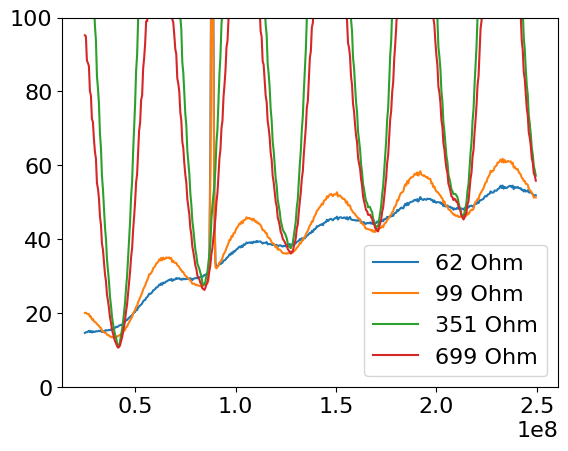

In [35]:
plt.plot(resample_axis, ohm_62.resample(resample_axis).s/T_62.s, label='62 Ohm')
plt.plot(resample_axis, ohm_99.resample(resample_axis).s/T_99.s, label='99 Ohm')
plt.plot(resample_axis, ohm_351.resample(resample_axis).s/T_351.s, label='351 Ohm')
plt.plot(resample_axis, ohm_699.resample(resample_axis).s/T_699.s, label='699 Ohm')
plt.ylim(0, 100)
plt.legend()

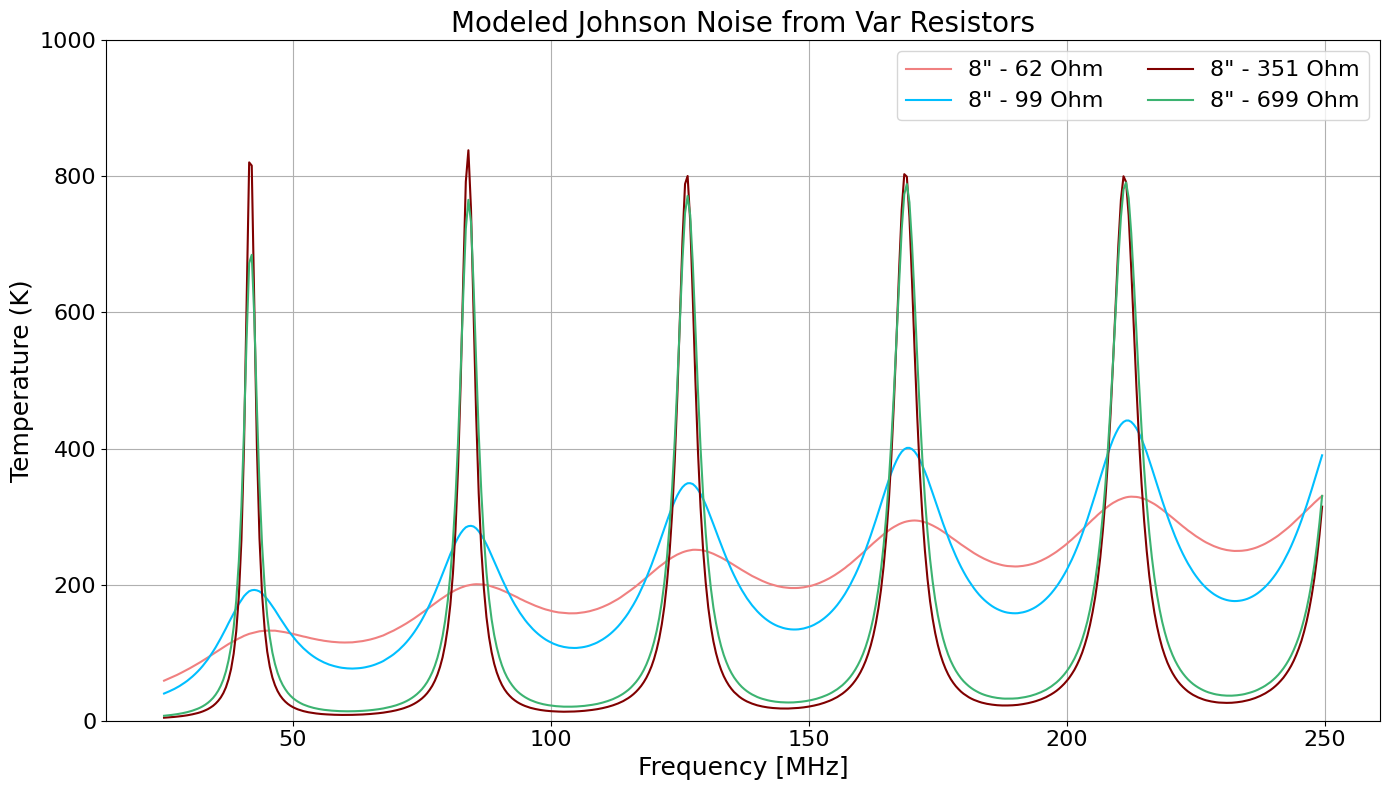

In [22]:
T_62 = LNAModel.T_delivered_from_s11(S11s.ntwk_dict['62 Ohm'], S11s.ntwk_dict['LNA'], 
                                         T_source=300, B=1e6, name='8" - 62 Ohm', colorcode='lightcoral')
T_99 = LNAModel.T_delivered_from_s11(S11s.ntwk_dict['99 Ohm'], S11s.ntwk_dict['LNA'], 
                                         T_source=300, B=1e6, name='8" - 99 Ohm', colorcode='deepskyblue')
T_351 = LNAModel.T_delivered_from_s11(S11s.ntwk_dict['351 Ohm'], S11s.ntwk_dict['LNA'],
                                        T_source=300, B=1e6, name='8" - 351 Ohm', colorcode='maroon')
T_699 = LNAModel.T_delivered_from_s11(S11s.ntwk_dict['699 Ohm'], S11s.ntwk_dict['LNA'], 
        T_source=300, B=1e6, name='8" - 699 Ohm', colorcode='mediumseagreen')
plotter.plot_spectra([T_62, T_99, T_351, T_699], title='Modeled Johnson Noise from Var Resistors',
        ylabel='Temperature (K)', y_range=(0, 1000))

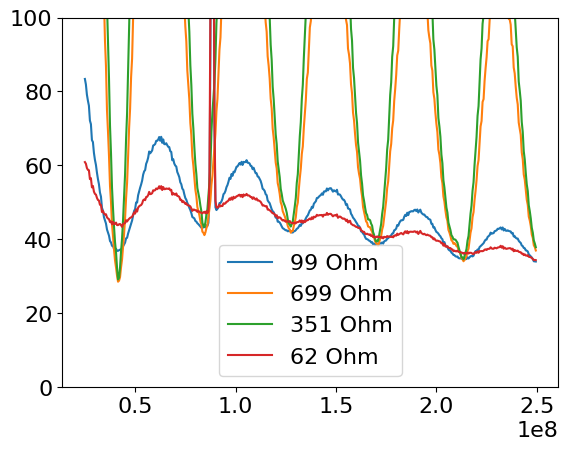

In [26]:
plt.plot(resample_axis, ohm_99.resample(resample_axis).s/T_99.s, label='99 Ohm')
plt.plot(resample_axis, ohm_699.resample(resample_axis).s/T_699.s, label='699 Ohm')
plt.plot(resample_axis, ohm_351.resample(resample_axis).s/T_351.s, label='351 Ohm')
plt.plot(resample_axis, ohm_62.resample(resample_axis).s/T_62.s, label='62 Ohm')
plt.ylim(0, 100)
plt.legend()

In [ ]:
def match_s11(s11, target_s11, tolerance=0.1, freq_window=3):
    """
    Parameters:
    s11 (rf.Network): The S11 parameters of the antenna to be matched.
    target_s11 (rf.Network): The target S11 parameters representing the desired impedance match.
    tolerance (float): The tolerance for considering a match.
    
    Returns:
    dict: A dictionary containing the best match frequency, S11 value, and the corresponding impedance.
    """ 
    
    match_mask = np.abs((np.real(s11.z[:, 0, 0]) - np.real(target_s11.z[:, 0, 0])) / np.real(target_s11.z[:, 0, 0])) < tolerance
    match_mask &= np.abs((np.imag(s11.z[:, 0, 0]) - np.imag(target_s11.z[:, 0, 0])) / np.imag(target_s11.z[:, 0, 0])) < tolerance

    matched_freqs = s11.f[match_mask]
    matched_s11_values = s11.s[match_mask, 0, 0]
    

    ntwk = rf.Network(f=matched_freqs, s=matched_s11_values[:, np.newaxis, np.newaxis])
    target_ntwk = rf.Network(f=matched_freqs, s=target_s11.s[match_mask])
    
    return ntwk, target_ntwk

In [69]:
ntwk, ant_ntwk = match_s11(S11s.ntwk_dict['99 Ohm'], ant_s11.ntwk_dict['Ant 1'], tolerance=0.2)
matched_ant1 = S_Params(ntwk_dict={'Ant 1': ant_ntwk, 'Matched from cable': ntwk})

ntwk, ant_ntwk = match_s11(S11s.ntwk_dict['62 Ohm'], ant_s11.ntwk_dict['Ant 1'], tolerance=0.2)
matched_ant1_62 = S_Params(ntwk_dict={'Ant 1': ant_ntwk, 'Matched from cable': ntwk})

(<Figure size 1400x1200 with 1 Axes>,
 <Axes: title={'center': 'Smith Chart'}, xlabel='Real', ylabel='Imaginary'>)

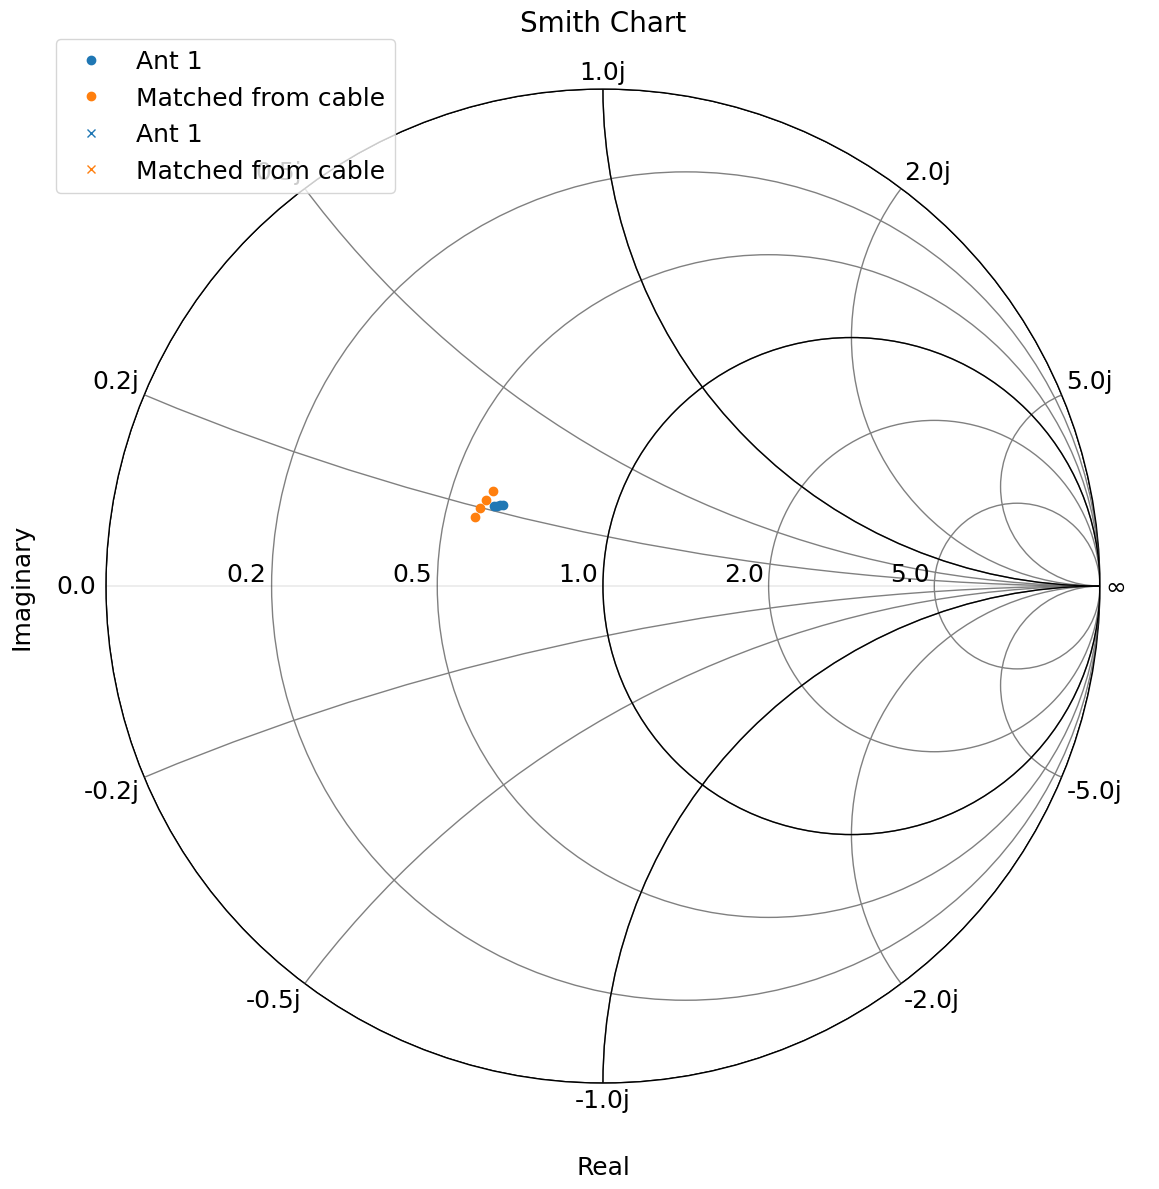

In [70]:
fig, ax = matched_ant1.plot_smith_chart(ls='', marker='o')
matched_ant1_62.plot_smith_chart(ls='', marker='x', fig=fig, ax=ax)

In [38]:
reflection_S11s = S_Params(ntwk_dict={label: reflection_proc.LNA_total_reflection(S11s.ntwk_dict[label], S11s.ntwk_dict['LNA']) 
                    for label in ['62 Ohm', '99 Ohm']}, colorcode={'62 Ohm': 'lightcoral', '99 Ohm': 'deepskyblue'})

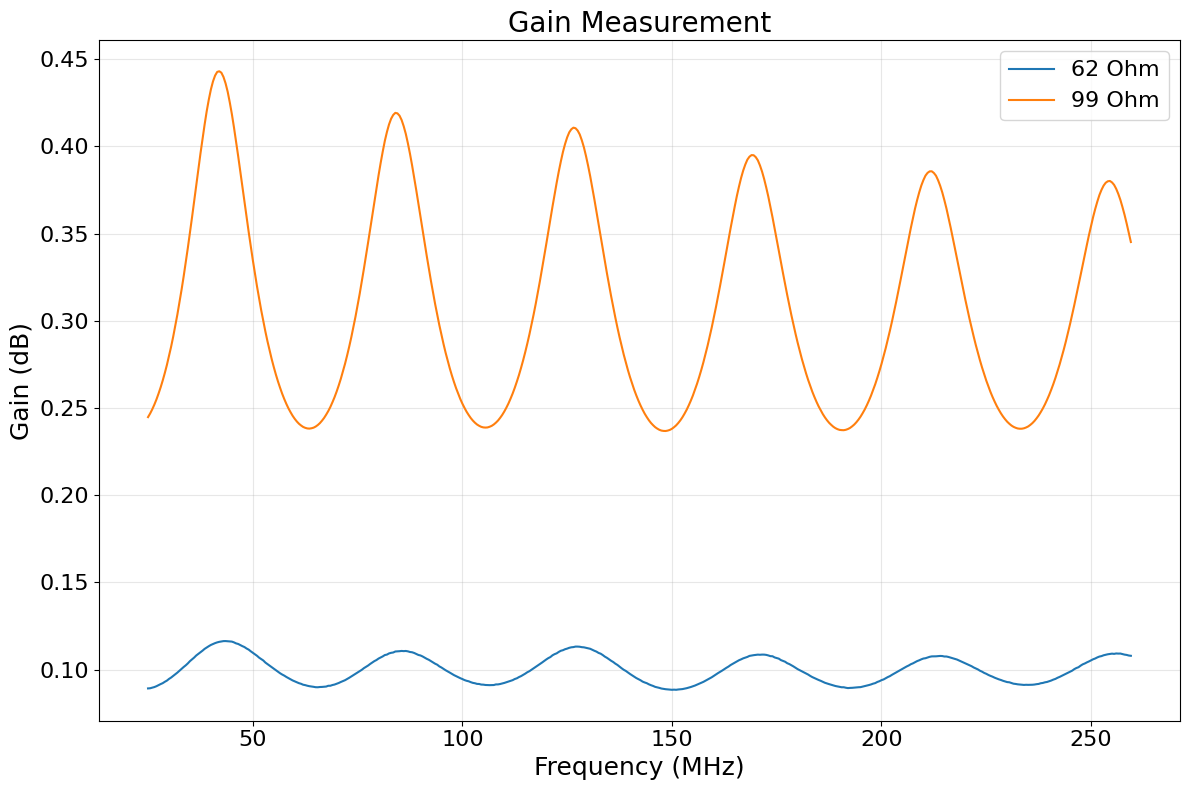

In [41]:
reflection_S11s.plot_gain(scale='linear')

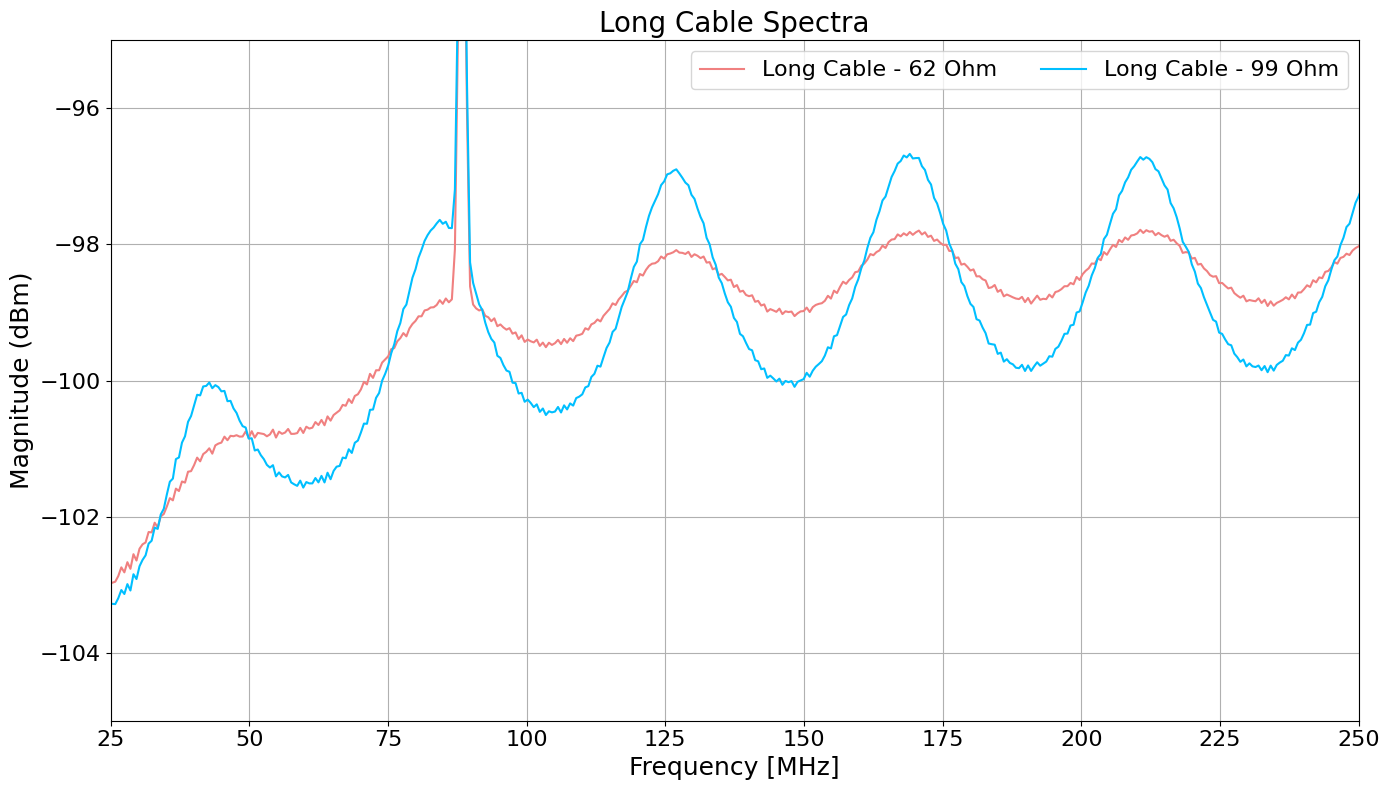

In [21]:
plotter.plot_spectra([ohm_62, ohm_99], freq_range=(25, 250), title="Long Cable Spectra", 
                     ylabel="Magnitude (dBm)", y_range=(-105, -95))